In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
df = pd.read_csv("Mall_Customers.csv")  # or your dataset
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,60,23,73
1,2,Male,36,15,78
2,3,Male,39,32,84
3,4,Male,38,15,68
4,5,Male,61,21,52


In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

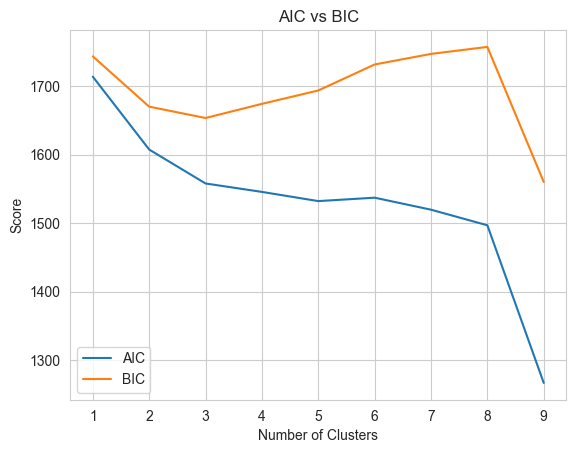

In [19]:
aics = []
bics = []
n_range = range(1, 10)

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=42, n_init=5)
    gmm.fit(X_scaled)
    aics.append(gmm.aic(X_scaled))
    bics.append(gmm.bic(X_scaled))

# Plot
plt.plot(n_range, aics, label='AIC')
plt.plot(n_range, bics, label='BIC')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.legend()
plt.title("AIC vs BIC")
plt.show()

In [20]:
gmm = GaussianMixture(n_components=3, covariance_type='full',
                      random_state=42)
gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [21]:
probs = gmm.predict_proba(X_scaled)
print(probs[:5])  # probability of each cluster

[[9.92702589e-18 4.18043270e-03 9.95819567e-01]
 [2.43025730e-26 9.02283647e-01 9.77163533e-02]
 [2.80444546e-20 7.13616979e-01 2.86383021e-01]
 [2.37736779e-23 8.28357450e-01 1.71642550e-01]
 [4.64311853e-14 1.90918970e-03 9.98090810e-01]]


In [22]:
labels = np.argmax(probs, axis=1)
df['GMM_Cluster'] = labels

In [23]:
log_likelihood = gmm.score(X_scaled)
print("Log-Likelihood:", log_likelihood)

Log-Likelihood: -3.966406950464062


In [24]:
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

AIC: 1644.562780185625
BIC: 1740.2139838155178


In [25]:
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.2719039682084945


In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = k_labels

print("KMeans Silhouette:", silhouette_score(X_scaled, k_labels))

KMeans Silhouette: 0.28255109452218663


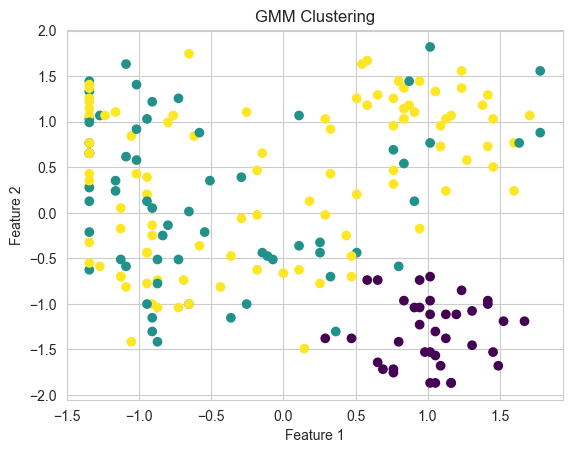

In [27]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("GMM Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

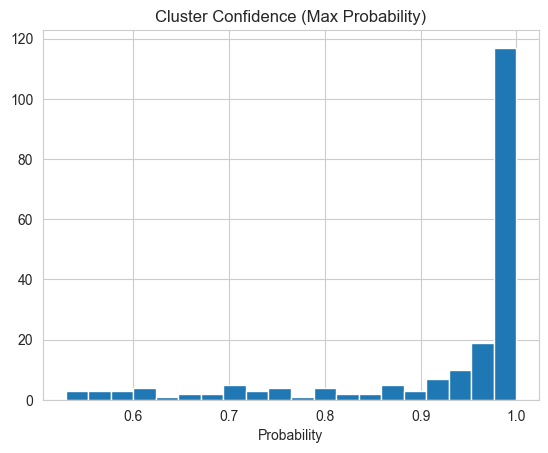

In [28]:
plt.hist(probs.max(axis=1), bins=20)
plt.title("Cluster Confidence (Max Probability)")
plt.xlabel("Probability")
plt.show()